# Video 3 — What Is a Process? Streams, Units, Variables
**Full Process Simulator — Block 1: Foundations**

In this notebook we turn today's three concepts into Python:
- A **stream** = flow, temperature, pressure, composition
- A **unit** = equipment that changes streams
- A **plant** = units connected by streams
- A **variable** = a number that changes over time


In [1]:
# A stream is a package of four pieces of information.
# Python's dictionary is perfect for "a bunch of labelled values".

# Our first stream: water feeding into a tank.
# Units: SI internally, always. kg/s, Kelvin, Pascal.
feed = {
    "flow": 2.5,              # mass flow rate [kg/s]
    "temperature": 293.15,    # temperature [K]  (293.15 K = 20 °C)
    "pressure": 200_000,      # pressure [Pa]    (200,000 Pa = 2 bar)
    "composition": {"water": 1.0},  # 100% water (fractions sum to 1.0)
}

print("Our first stream:")
for key, value in feed.items():
    print(f"  {key}: {value}")

Our first stream:
  flow: 2.5
  temperature: 293.15
  pressure: 200000
  composition: {'water': 1.0}


In [2]:
# Watch me create a bug on purpose.
# Second stream, but with a typo in one key name:

hot_feed = {
    "flow": 1.0,
    "temprature": 353.15,     # <-- TYPO. Python does NOT complain.
    "pressure": 150_000,
    "composition": {"water": 1.0},
}

# The dictionary happily accepts the typo. Now try to read the temperature:
print(hot_feed.get("temperature"))   # -> None. The data is "missing".
print(hot_feed.get("temprature"))    # -> 353.15. It's hiding under the typo.

# In a 500-line simulator, this bug would surface days later, far from
# where we made it. Dictionaries have no fixed shape - nothing enforces
# that every stream has the same four fields, spelled the same way.
# We need a template. That's what a class is.

None
353.15


In [5]:
# A class is a template. Define the shape ONCE, then stamp out as many
# streams as we want - and they all have the same four fields, guaranteed.

class Stream:
    """Material flowing from one place to another.

    Fully described by four things:
    how much, how hot, how squeezed, what's in it.
    All values in SI units.
    """

    def __init__(self, name, flow=0.0, temperature=293.15,
                 pressure=101_325, composition=None):
        self.name = name                  # a human-friendly label
        self.flow = flow                  # mass flow [kg/s]
        self.temperature = temperature    # [K]
        self.pressure = pressure          # [Pa], default = atmospheric
        # default composition: pure water (safe default for early videos)
        self.composition = composition if composition else {"water": 1.0}

    def temperature_C(self):
        """Convenience: temperature in Celsius for humans.
        Engine thinks in Kelvin, screen speaks Celsius."""
        return self.temperature - 273.15

    def describe(self):
        print(f"Stream '{self.name}':")
        print(f"  flow:        {self.flow} kg/s")
        print(f"  temperature: {self.temperature} K ({self.temperature_C():.1f} °C)")
        print(f"  pressure:    {self.pressure/100_000:.2f} bar")
        print(f"  composition: {self.composition}")


# Stamp out two streams from the same template:
feed = Stream("feed", flow=2.5, temperature=293.15, pressure=200_000)
product = Stream("product", flow=2.5, temperature=293.15, pressure=101_325)

feed.describe()
print()
product.describe()

# Try to typo now:
# feed.temprature  ->  AttributeError. Python STOPS us. That's the point.

Stream 'feed':
  flow:        2.5 kg/s
  temperature: 293.15 K (20.0 °C)
  pressure:    2.00 bar
  composition: {'water': 1.0}

Stream 'product':
  flow:        2.5 kg/s
  temperature: 293.15 K (20.0 °C)
  pressure:    1.01 bar
  composition: {'water': 1.0}


In [6]:
# A unit is equipment that does something to streams.
# For now, a unit just needs: a name, what kind of thing it is,
# an inlet stream and an outlet stream. Behaviour comes in Block 2.

class Unit:
    """A piece of process equipment. Streams connect into and out of it."""

    def __init__(self, name, kind):
        self.name = name      # e.g. "T-101"
        self.kind = kind      # e.g. "tank", "pump", "valve"
        self.inlet = None     # a Stream (or None if not connected yet)
        self.outlet = None    # a Stream

    def connect(self, inlet=None, outlet=None):
        if inlet is not None:
            self.inlet = inlet
        if outlet is not None:
            self.outlet = outlet


# Build the equipment for our first mini plant:
tank = Unit("T-101", "tank")
pump = Unit("P-101", "pump")
valve = Unit("V-101", "valve")

print(f"Created unit {tank.name} ({tank.kind})")
print(f"Created unit {pump.name} ({pump.kind})")
print(f"Created unit {valve.name} ({valve.kind})")

Created unit T-101 (tank)
Created unit P-101 (pump)
Created unit V-101 (valve)


In [7]:
# A plant = units connected by streams. Boxes and arrows.
# Layout:  feed -> [T-101 tank] -> [P-101 pump] -> [V-101 valve] -> product

# The arrows (streams):
feed          = Stream("feed",          flow=2.5, pressure=200_000)
tank_to_pump  = Stream("tank_to_pump",  flow=2.5, pressure=101_325)
pump_to_valve = Stream("pump_to_valve", flow=2.5, pressure=400_000)  # pump added pressure
product       = Stream("product",       flow=2.5, pressure=101_325)  # valve removed it

# Draw the P&ID in code:
tank.connect(inlet=feed,          outlet=tank_to_pump)
pump.connect(inlet=tank_to_pump,  outlet=pump_to_valve)
valve.connect(inlet=pump_to_valve, outlet=product)

# The plant is just an ordered list of units:
plant = [tank, pump, valve]

# Walk the graph and print it - our first "HMI":
print("=" * 55)
print("  OUR FIRST PLANT")
print("=" * 55)
for unit in plant:
    print(f"  [{unit.inlet.name}] ──▶ ({unit.name} {unit.kind}) ──▶ [{unit.outlet.name}]")
print("=" * 55)

# Notice the pressures along the way:
print("\nPressure through the plant:")
for stream in [feed, tank_to_pump, pump_to_valve, product]:
    print(f"  {stream.name:14s}: {stream.pressure/100_000:.2f} bar")

# Pump ADDS pressure, valve REMOVES it. We typed those numbers in by hand
# today. From Block 2 onwards, the physics engine calculates them.

  OUR FIRST PLANT
  [feed] ──▶ (T-101 tank) ──▶ [tank_to_pump]
  [tank_to_pump] ──▶ (P-101 pump) ──▶ [pump_to_valve]
  [pump_to_valve] ──▶ (V-101 valve) ──▶ [product]

Pressure through the plant:
  feed          : 2.00 bar
  tank_to_pump  : 1.01 bar
  pump_to_valve : 4.00 bar
  product       : 1.01 bar


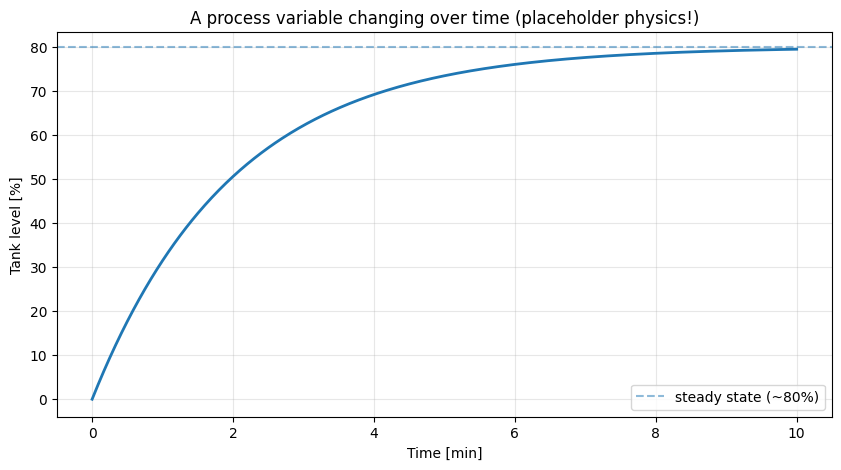

In [8]:
# A variable is a number that changes over time. Let's watch one change.
#
# ⚠️  HONESTY FLAG: the curve below is a PLACEHOLDER SHAPE, not physics.
#     I picked a formula that *looks like* a tank filling up.
#     From Video 9, this exact plot will come from a real mass balance.

import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 600, 601)          # 10 minutes, one point per second

# Fake "tank level" rising toward steady state (placeholder curve):
level = 80 * (1 - np.exp(-time / 120))   # settles toward 80%

plt.figure(figsize=(10, 5))
plt.plot(time / 60, level, linewidth=2)
plt.axhline(80, linestyle="--", alpha=0.5, label="steady state (~80%)")
plt.xlabel("Time [min]")
plt.ylabel("Tank level [%]")
plt.title("A process variable changing over time (placeholder physics!)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Read the plot:
#  - Early on: level rises fast -> inflow >> outflow -> ACCUMULATION.
#  - Later: curve flattens -> inflow ≈ outflow -> steady state.
#
# "Accumulation = in - out" is the entire next video.
# You already understand it. Video 4 just puts numbers on it.

## What we built
- `Stream` class — flow, temperature, pressure, composition (SI units internally)
- `Unit` class — name, kind, inlet, outlet
- Our first plant: feed → tank → pump → valve → product
- Our first trend plot (placeholder physics)

## Next video
**Video 4 — Introduction to mass balance.** What goes in must come out
or stay inside. The one sentence the whole simulator stands on.
